In [98]:
import karateclub as kc
import matplotlib.pyplot as plt
import networkx as nx
from networkx.drawing.nx_pydot import graphviz_layout
import numpy as np
import os
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import pydot
import random
import warnings

from reeb_utils import collapse_traj, do_reeb_for_start_end, do_reeb_for_explore_node
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics.cluster import adjusted_rand_score, normalized_mutual_info_score


warnings.filterwarnings("ignore")
pd.options.mode.chained_assignment = None

import logging
logger = logging.getLogger()
logger.setLevel(logging.CRITICAL)

## Load data

In [77]:
# load data into dataframe
df = pd.read_csv("data/MLINDIV_train_full.csv")

test_df = df[df["eprocs"].str.contains("Test")]

test_df["subj_mean_acc"] = test_df.groupby("Subject")["accuracy"].transform("mean")
test_df["path_mean_acc"] = test_df.groupby(["StartAt", "EndAt"])["accuracy"].transform("mean")

test_df['quartile'] = (
    pd.qcut(test_df['subj_mean_acc'], 4, labels=[1, 2, 3, 4])
)

test_df["path_mean_acc_by_Q"] = test_df.groupby(["StartAt", "EndAt", "quartile"])["accuracy"].transform("mean")

# # Calculate min path dist; first set v high for the wrong people
# # Note: there's definitely a smarter way to do this in pandas
# test_df["fake_dist"] = test_df["trajs"].apply(len)
# test_df.loc[~test_df["accuracy"], "fake_dist"] = 999

# test_df["min_dist"] = test_df.groupby("StartEnd")["fake_dist"].transform("min")

## Load subject info

In [80]:
subject_df = pd.read_csv("data/MLINDIV_subject_info.csv")
subject_df["Subject"] = pd.to_numeric(subject_df["Spatial Neuro ID"], errors="coerce")
subject_df = subject_df[~subject_df["Subject"].isna()]

subject_df["is_man"] = (subject_df["Sex"] == "M")

merged_df = pd.merge(test_df, subject_df, on="Subject")
# merged_df[["Sex", "Proportion Correct (new version)", "subj_mean_acc"]]

## Compute Flow Trees

In [89]:
## BY PATH
flow_trees = []
flow_trees_by_q = {i+1: [] for i in range(4)}
accs = []
for (start_node, end_node), group in test_df.groupby(["StartAt", "EndAt"]):
    G = do_reeb_for_start_end(test_df, start_node, end_node, 0, use_turns=False) # 0 means all quartiles
    new_G = nx.relabel.convert_node_labels_to_integers(G, first_label=0, ordering='default') #first_label is the starting integer label, in this case zero
    flow_trees.append(new_G)
    accs.append(group["path_mean_acc"].iloc[0])

    for i in range(1,5):
        G = do_reeb_for_start_end(test_df, start_node, end_node, i, use_turns=False)
        new_G = nx.relabel.convert_node_labels_to_integers(G, first_label=0, ordering='default') #first_label is the starting integer label, in this case zero
        flow_trees_by_q[i].append(new_G)
        # accs_by_q.append(group[group["quartile"]==i]["path_mean_acc_by_Q"].iloc[0])

## Compute features

### Baselines

In [15]:
# baseline_features

### Tree features

In [135]:
def extract_tree_features(graph, root):
    # Number of Nodes
    num_nodes = graph.number_of_nodes()
    
    # Number of Edges
    num_edges = graph.number_of_edges()
    
    # Tree Depth (Height)
    def tree_depth(graph, root):
        depths = nx.single_source_shortest_path_length(graph, root)
        return max(depths.values())
    
    depth = tree_depth(graph, root)
    
    # Average Node Degree
    avg_degree = np.mean([degree for node, degree in graph.degree()])
    
    # Diameter
    diameter = nx.diameter(graph)
    
    # Number of Leaves
    num_leaves = sum(1 for node in graph.nodes() if graph.degree(node) == 1)
    
    # Average Path Length
    avg_path_length = nx.average_shortest_path_length(graph)
    
    # Branching Factor
    branching_factors = [len(list(graph.neighbors(node))) for node in graph.nodes()]
    avg_branching_factor = np.mean(branching_factors)
    
    # Clustering Coefficient
    clustering_coeffs = nx.clustering(graph)
    avg_clustering_coeff = np.mean(list(clustering_coeffs.values()))
    
    # Put all features in a list
    features = [
        num_nodes,
        num_edges,
        depth,
        avg_degree,
        diameter,
        num_leaves,
        avg_path_length,
        avg_branching_factor,
        # avg_clustering_coeff
    ]
    
    return features
    
tree_features_by_q = []
for q in flow_trees_by_q:
    tree_features = np.array([extract_tree_features(ft, 0) for ft in flow_trees_by_q[q]])
    tree_features = (tree_features - tree_features.mean(axis=0)) / tree_features.std(axis=0)
    
    tree_features_by_q.append(tree_features)

tree_features_by_q = np.array(tree_features_by_q)
tree_features_by_q.shape

(4, 72, 8)

### Tree embeddings

In [101]:
all_flow_trees = []
for q in flow_trees_by_q:
    all_flow_trees.extend(flow_trees_by_q[q])

explore_model = kc.Graph2Vec(dimensions=64)
explore_model.fit(all_flow_trees)
    
tree_embeddings_by_q = np.array([explore_model.infer(flow_trees_by_q[q]) for q in flow_trees_by_q])
print(tree_embeddings_by_q.shape)

(4, 72, 64)


### Tree shapes

In [103]:
max_num_nodes = max(all_flow_trees, key=lambda x: x.number_of_nodes()).number_of_nodes()

# convert Flow Trees to padded adjacency matrices
padded_adj_mats = []
for ft in all_flow_trees:
    adj_mat = nx.adjacency_matrix(ft).todense()

    amt_to_pad = max_num_nodes - ft.number_of_nodes()
    padded_adj_mat = np.pad(adj_mat, pad_width=(0, amt_to_pad))

    padded_adj_mats.append(padded_adj_mat)

padded_adj_mats = np.array(padded_adj_mats)

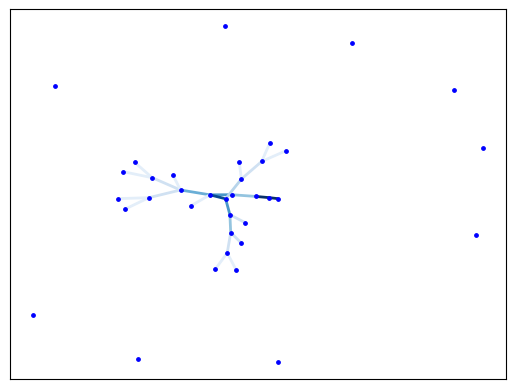

In [104]:
## STOLEN FROM GEOMSTATS DEMO
##  https://github.com/geomstats/geomstats/blob/main/notebooks/20_real_world_applications__graph_space.ipynb
import matplotlib.pyplot as plt
import networkx as nx

import geomstats.backend as gs
import geomstats.datasets.utils as data_utils
from geomstats.geometry.stratified.graph_space import GraphSpace
from geomstats.learning.aac import AAC

gs.random.seed(2020)

mammals_obs = nx.from_numpy_array(padded_adj_mats[5])
pos = nx.kamada_kawai_layout(mammals_obs)
edges, weights = zip(*nx.get_edge_attributes(mammals_obs, "weight").items())

pos = nx.spring_layout(mammals_obs)
nx.draw_networkx_nodes(mammals_obs, pos, node_color="b", node_size=6)
nx.draw_networkx_edges(
    mammals_obs,
    pos,
    edgelist=edges,
    edge_color=weights,
    width=2.0,
    edge_cmap=plt.cm.Blues,
    edge_vmin=0.0,
    edge_vmax=10.0,
)

## normal to have all the floating nodes; this is what happens when you are padded

In [109]:
total_space = GraphSpace(n_nodes=padded_adj_mats.shape[1])
total_space.equip_with_group_action()
total_space.equip_with_quotient()

aac_fm = AAC(total_space, estimate="frechet_mean", max_iter=100)

In [110]:
aac_fm.fit(padded_adj_mats)

_AACFrechetMean(max_iter=100,
                space=<geomstats.geometry.stratified.graph_space.GraphSpace object at 0x2f2d1f050>,
                total_space_estimator_kwargs={})

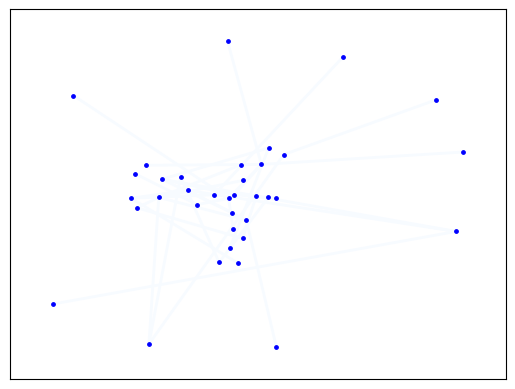

In [112]:
total_flow_trees_fm_mst = nx.minimum_spanning_tree(nx.from_numpy_array(aac_fm.estimate_))
edges, weights = zip(*nx.get_edge_attributes(total_flow_trees_fm_mst, "weight").items())

nx.draw_networkx_nodes(total_flow_trees_fm_mst, pos, node_color="b", node_size=6)
nx.draw_networkx_edges(
    total_flow_trees_fm_mst,
    pos,
    edgelist=edges,
    edge_color=weights,
    width=2.0,
    edge_cmap=plt.cm.Blues,
    edge_vmin=0.0,
    edge_vmax=10.0,
)

In [152]:
graph_space = total_space.quotient
graph_space

point_a, point_b, point_c = padded_adj_mats[0], padded_adj_mats[1], padded_adj_mats[-1]

dist_total = total_space.metric.dist(point_a, point_b)
dist_quotient = graph_space.metric.dist(point_a, point_b)

print(f"dist quotient <= dist total:\n{dist_quotient} <= {dist_total}")

print("dist a to c", graph_space.metric.dist(point_a, point_c))

dist quotient <= dist total:
23.15167380558045 <= 29.257477676655586
dist a to c 21.95449840010015


## Hypothesis testing

### Tree features

In [142]:
# print(tree_features_by_q)
# tree_features_by_q = np.nan_to_num(tree_features_by_q)

q12_tree_features = np.concatenate(tree_features_by_q[0:2, :])
q34_tree_features = np.concatenate(tree_features_by_q[2:4, :])

between_group_dist = pdist(np.concatenate(tree_features_by_q))
# print(between_group_dist)
q12_dist = pdist(q12_tree_features)
q34_dist = pdist(q34_tree_features)

# Perform a t-test on distances between the two groups
t_stat, p_value = stats.ttest_ind(between_group_dist, np.concatenate([q12_dist, q34_dist]))

print(f"T-statistic: {t_stat}, P-value: {p_value}")

T-statistic: 0.6821966119938591, P-value: 0.4951171886322788


### Tree embeddings

In [143]:

q12_tree_embeddings = np.concatenate(tree_embeddings_by_q[0:2, :])
q34_tree_embeddings = np.concatenate(tree_embeddings_by_q[2:4, :])

between_group_dist = pdist(np.concatenate(tree_embeddings_by_q))

q12_dist = pdist(q12_tree_embeddings)
q34_dist = pdist(q34_tree_embeddings)

print(np.mean(between_group_dist), np.std(between_group_dist))
print(np.mean(q12_dist), np.std(q12_dist))
print(np.mean(q34_dist), np.std(q34_dist))

# Perform a t-test on distances between the two groups
t_stat, p_value = stats.ttest_ind(between_group_dist, np.concatenate([q12_dist, q34_dist]))

print(f"T-statistic: {t_stat}, P-value: {p_value}")

0.356759531607 0.24249265570132938
0.2364820233607178 0.1679620530610586
0.2444099012343723 0.19372670254172367
T-statistic: 60.86907658059088, P-value: 0.0


In [148]:
# try hotelling t test?
from hotelling.stats import hotelling_t2

t2_statistic, f, p, s = hotelling_t2(q12_tree_embeddings, q34_tree_embeddings)

# Output results
print("T²-statistic:", t2_statistic)
print("P-value:", p_value)

# Interpretation
alpha = 0.05
if p_value < alpha:
    print("Reject the null hypothesis: The two sets come from different distributions.")
else:
    print("Fail to reject the null hypothesis: The two sets come from the same distribution.")


T²-statistic: 509.7336075499657
P-value: 0.0
Reject the null hypothesis: The two sets come from different distributions.


### Tree shapes

In [117]:
num_in_half = padded_adj_mats.shape[0]//2
q12_flow_trees = padded_adj_mats[:num_in_half, :, :]
q34_flow_trees = padded_adj_mats[num_in_half:, :, :]

In [118]:
from scipy.spatial.distance import pdist, squareform

def flatten_mats(mats):
    flat_mats = np.zeros((mats.shape[0], mats.shape[1]*mats.shape[2]))
    for i, m in enumerate(mats):
        flat_mats[i,:] = m.flatten()
    return flat_mats

def unflatten_mat(mat):
    d1_size = int(np.sqrt(mat.shape[0]))
    if d1_size**2 != mat.shape[0]: 
        print("uhoh mats isn't a square matrix")
        return

    return np.reshape(mat, (d1_size, d1_size))
    
def dist_metric_with_flat(m1, m2):
    unflat_m1 = unflatten_mat(m1)
    unflat_m2 = unflatten_mat(m2)

    return graph_space.metric.dist(unflat_m1, unflat_m2)
    
flat_all = flatten_mats(padded_adj_mats)
flat_q12 = flatten_mats(q12_flow_trees)
flat_q34 = flatten_mats(q34_flow_trees)

between_group_dist = pdist(flat_all, metric=dist_metric_with_flat)
q12_dist = pdist(flat_q12, metric=dist_metric_with_flat)
q34_dist = pdist(flat_q34, metric=dist_metric_with_flat)

In [120]:
from scipy import stats

# Perform a t-test on distances between the two groups
t_stat, p_value = stats.ttest_ind(between_group_dist, np.concatenate([q12_dist, q34_dist]))

print(f"T-statistic: {t_stat}, P-value: {p_value}")

T-statistic: 16.47728317663411, P-value: 7.20499963107399e-61


In [153]:
print(np.mean(between_group_dist), np.std(between_group_dist))
print(np.mean(np.concatenate([q12_dist, q34_dist])), np.std(np.concatenate([q12_dist, q34_dist])))

0.356759531607 0.24249265570132938
0.24044596229754508 0.18134595690277347


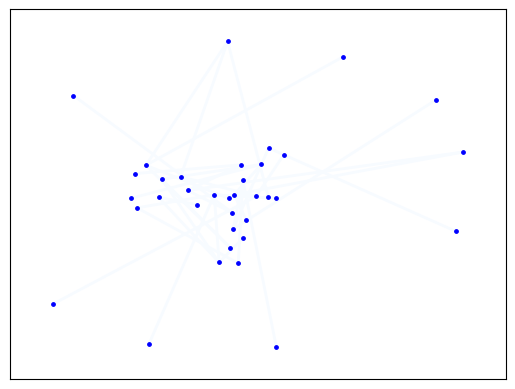

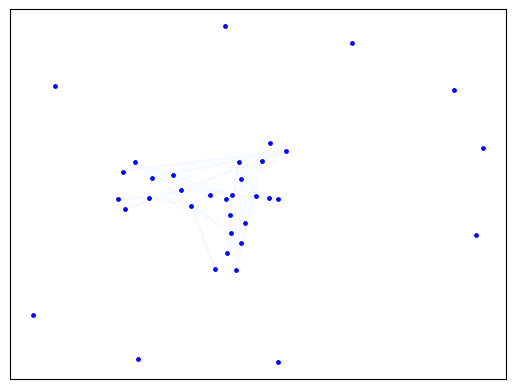

In [151]:
## Look at means for both sets of trees

def compute_mean_graph(padded_adj_mats):
    total_space = GraphSpace(n_nodes=padded_adj_mats.shape[1])
    total_space.equip_with_group_action()
    total_space.equip_with_quotient()
    
    aac_fm = AAC(total_space, estimate="frechet_mean", max_iter=200)
    
    aac_fm.fit(padded_adj_mats)
    
    total_flow_trees_fm_mst = nx.minimum_spanning_tree(nx.from_numpy_array(aac_fm.estimate_))
    edges, weights = zip(*nx.get_edge_attributes(total_flow_trees_fm_mst, "weight").items())
    
    nx.draw_networkx_nodes(total_flow_trees_fm_mst, pos, node_color="b", node_size=6)
    nx.draw_networkx_edges(
        total_flow_trees_fm_mst,
        pos,
        edgelist=edges,
        edge_color=weights,
        width=2.0,
        edge_cmap=plt.cm.Blues,
        edge_vmin=0.0,
        edge_vmax=10.0,
    )


    plt.show()
    return total_flow_trees_fm_mst

mst_12 = compute_mean_graph(q12_flow_trees)
mst_34 = compute_mean_graph(q34_flow_trees)